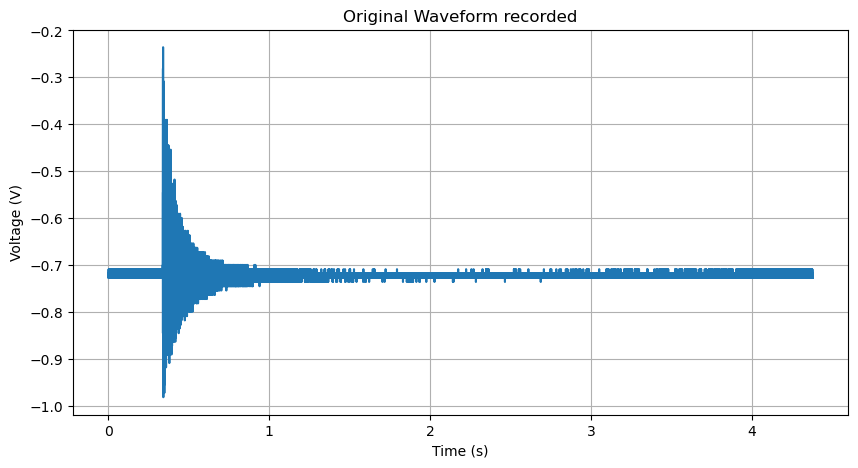

In [6]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# Load the CSV file
filepath = 'Mass Dataset.csv'

# Load the data, skipping the second row which contains units
df = pd.read_csv(filepath, skiprows=[1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df.iloc[:, 0], df.iloc[:, 1])
plt.title("Original Waveform recorded")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

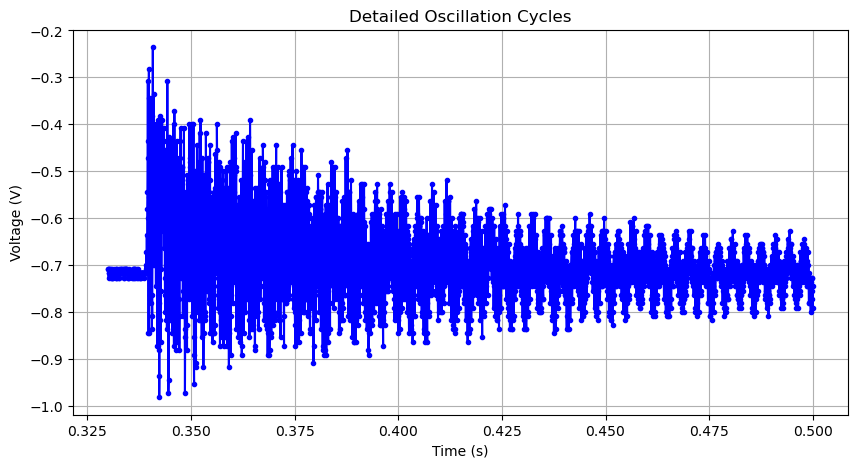

In [7]:
# Extract the actual trigger
df_cycles = df[(df['Time'] >= 0.33) & (df['Time'] <= 0.50)]

plt.figure(figsize=(10, 5))
plt.plot(df_cycles['Time'], df_cycles['Channel A'], 'b.-')
plt.title("Detailed Oscillation Cycles")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

Offset value: -0.7117359942014084
Number of samples: 7100
Peak frequency from FFT: 290.1408450701324 Hz


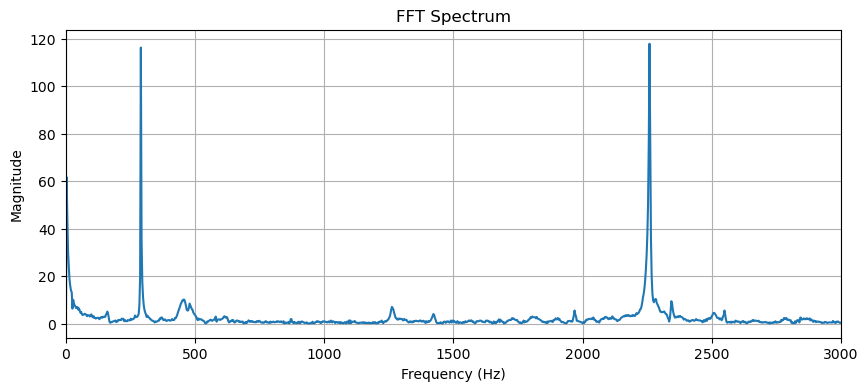

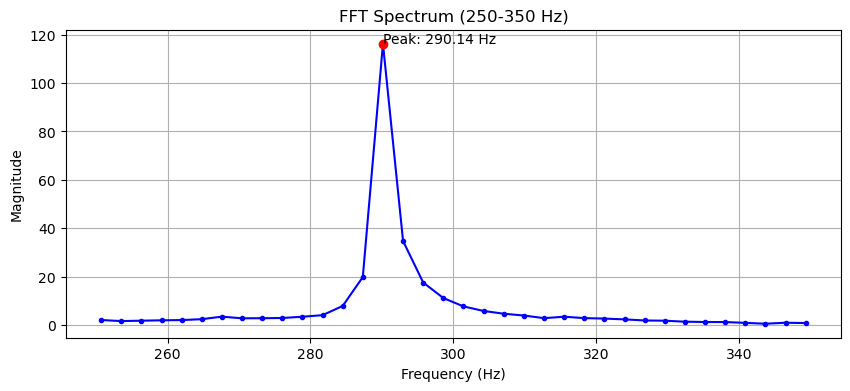

In [8]:
# Apply FFT to the extracted cycles to an interval of 'Pure unforced free vibration' (0.345 to 0.70 seconds)
df_fft = df[(df['Time'] >= 0.345) & (df['Time'] <= 0.70)]

# Sampling interval dt
dt = df_fft['Time'].iloc[1] - df_fft['Time'].iloc[0]
fs = 1.0 / dt

# Removing the offset value from the signal which centers the oscillation to zero
y = df_fft['Channel A'].values - np.mean(df_fft['Channel A'].values)
print(f"Offset value: {np.mean(df_fft['Channel A'].values)}")

# FFT
n = len(y)
print(f"Number of samples: {n}")
yf = np.fft.rfft(y)
xf = np.fft.rfftfreq(n, d=dt)

# include values from 250 to 350 Hz
xf_new = xf[(xf >= 250) & (xf <= 350)]
yf_new = yf[(xf >= 250) & (xf <= 350)]

# Peak frequency calculation
# Mass3 has a second mode near 2259 Hz which is almost as tall as the
# fundamental, so argmax must be restricted to the band above.
band = (xf >= 250) & (xf <= 350)
peak_idx = int(np.where(band)[0][np.argmax(np.abs(yf[band]))])
peak_freq = xf[peak_idx]
print(f"Peak frequency from FFT: {peak_freq} Hz")

plt.figure(figsize=(10, 4))
plt.plot(xf, np.abs(yf))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 3000)
plt.grid(True)
plt.show()

# plot new graph with the new frequency range with data points marked
plt.figure(figsize=(10, 4))
plt.plot(xf_new, np.abs(yf_new), 'b.-')
plt.title("FFT Spectrum (250-350 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
# Mark the peak frequency on the plot
plt.plot(peak_freq, np.abs(yf[peak_idx]), 'ro')
plt.annotate(f'Peak: {peak_freq:.2f} Hz', xy=(peak_freq, np.abs(yf[peak_idx])))
plt.grid(True)
plt.show()

Offset value: -0.7093212936875001


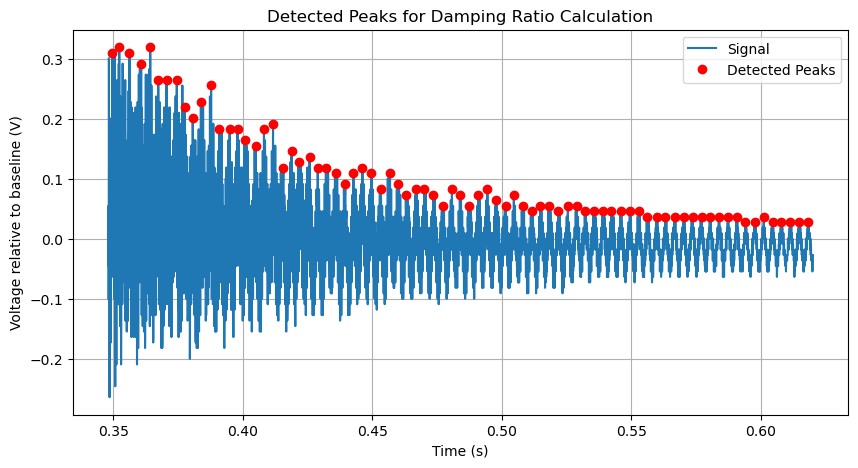

In [9]:
# Calculation of damping ratio using logarithmic decrement method
df_peaks = df[(df['Time'] >= 0.348) & (df['Time'] <= 0.62)].copy()
time = df_peaks['Time'].values
val = df_peaks['Channel A'].values

baseline = np.mean(val)   # Calculate the mean of the signal to use as a baseline
val_detrend = val - baseline

print(f"Offset value: {baseline}")   # check console for result

# Three params - value with offset removed, min distance between peaks min to avoid false peaks,
# and prominence of peaks (min value for it to be counted as a peak).
peaks, _ = find_peaks(val_detrend, distance=int(fs/400), prominence=0.01)

peak_times = time[peaks]
peak_vals = val_detrend[peaks]

plt.figure(figsize=(10, 5))
plt.plot(time, val_detrend, label='Signal')
plt.plot(peak_times, peak_vals, 'ro', label='Detected Peaks')
plt.title("Detected Peaks for Damping Ratio Calculation")
plt.xlabel("Time (s)")
plt.ylabel("Voltage relative to baseline (V)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
fd = peak_freq
wd = 2 * np.pi * fd

fit_mask = peak_vals > 0.03   # filter noise (this file quantizes at ~9 mV)
fit_times = peak_times[fit_mask]
fit_log_vals = np.log(peak_vals[fit_mask])

slope, intercept = np.polyfit(fit_times - fit_times[0], fit_log_vals, 1)

decay_constant = -slope
zeta = decay_constant / np.sqrt(wd**2 + decay_constant**2)
fn = fd / np.sqrt(1 - zeta**2)

print(f"Decay constant (sigma): {decay_constant}")
print(f"Damping ratio (zeta): {zeta}")
print(f"Natural Frequency (fn): {fn} Hz")

# zeta is the damping ratio

Decay constant (sigma): 9.462221306949708
Damping ratio (zeta): 0.0051903723099887816
Natural Frequency (fn): 290.14475334116355 Hz


In [11]:
# ---------------- Quality Factor (self-contained) ----------------
# needs only: decay_constant (sigma, 1/s) and fd (damped frequency, Hz)
wd = 2 * np.pi * fd
zeta = decay_constant / np.sqrt(wd**2 + decay_constant**2)

Q = 1 / (2 * zeta)
print(f"Damping ratio (zeta): {zeta}")
print(f"Quality factor (Q): {Q}")

Damping ratio (zeta): 0.0051903723099887816
Quality factor (Q): 96.33220319046453


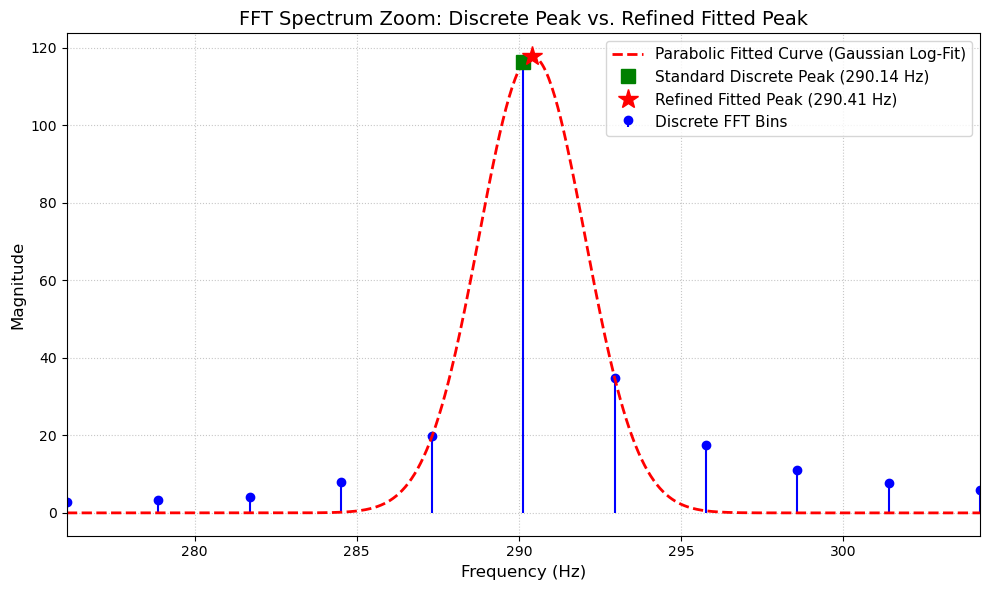

In [12]:
# Parabolic (Gaussian log-fit) refinement of the peak
mag = np.abs(yf)
df_bin = xf[1] - xf[0]
standard_peak_freq = xf[peak_idx]

eps = 1e-20
l_km1, l_k, l_kp1 = (np.log(mag[peak_idx-1] + eps),
                     np.log(mag[peak_idx]   + eps),
                     np.log(mag[peak_idx+1] + eps))

a = 0.5 * (l_km1 - 2*l_k + l_kp1)
b = 0.5 * (l_kp1 - l_km1)
c = l_k

delta_hat         = -b / (2*a)
refined_peak_freq = (peak_idx + delta_hat) * df_bin
refined_mag       = np.exp(c - b**2 / (4*a))

# Plot
SPAN = 5
delta_fine     = np.linspace(-SPAN, SPAN, 600)
freq_fine      = (peak_idx + delta_fine) * df_bin
magnitude_fine = np.exp(a*delta_fine**2 + b*delta_fine + c)

nb = np.arange(peak_idx - SPAN, peak_idx + SPAN + 1)

plt.figure(figsize=(10, 6))
plt.stem(xf[nb], mag[nb], linefmt='b-', markerfmt='bo', basefmt=" ",
         label='Discrete FFT Bins')
plt.plot(freq_fine, magnitude_fine, 'r--', linewidth=2,
         label='Parabolic Fitted Curve (Gaussian Log-Fit)')
plt.plot(standard_peak_freq, mag[peak_idx], 'gs', markersize=10,
         label=f'Standard Discrete Peak ({standard_peak_freq:.2f} Hz)')
plt.plot(refined_peak_freq, refined_mag, 'r*', markersize=15,
         label=f'Refined Fitted Peak ({refined_peak_freq:.2f} Hz)')
plt.title("FFT Spectrum Zoom: Discrete Peak vs. Refined Fitted Peak", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Magnitude", fontsize=12)
plt.xlim(standard_peak_freq - SPAN*df_bin, standard_peak_freq + SPAN*df_bin)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()